In [3]:
#importamos librerias (pandas,numpy,matplotlib)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Creacion de dataframe para la practica

df = pd.DataFrame({
    'Ciudad': ['Buenos Aires', 'Buenos Aires', 'Córdoba', 'Córdoba', 'Rosario', 'Rosario', 'Mendoza', 'Mendoza'],
    'Producto': ['Notebook', 'Tablet', 'Notebook', 'Tablet', 'Notebook', 'Tablet', 'Notebook', 'Tablet'],
    'Vendedor': ['Lucía', 'Juan', 'Lucía', np.nan, 'Juan', 'Lucía', np.nan, 'Juan'],
    'Cantidad': [10, 5, np.nan, 8, 7, 3, 6, np.nan],
    'Precio': [1000, 500, 1200, 600, np.nan, 550, 1100, 580]
})
#creacion de una nueva columna con el total de venta de cada producto

df['Total'] = df['Cantidad'] * df['Precio']

#analisis del dataframe para determinar valores null

df.isnull().sum()

Ciudad      0
Producto    0
Vendedor    2
Cantidad    2
Precio      1
Total       3
dtype: int64

In [ ]:
#creacion de dataframe filtro donde se ve el total de venta por producto en cada ciudad
ventas_ciudad=df.groupby(['Ciudad','Producto'])['Total'].sum().reset_index()
ventas_ciudad

,Ciudad,Producto,Total
0,Buenos Aires,Notebook,10000.0
1,Buenos Aires,Tablet,2500.0
2,Córdoba,Notebook,0.0
3,Córdoba,Tablet,4800.0
4,Mendoza,Notebook,6600.0
5,Mendoza,Tablet,0.0
6,Rosario,Notebook,0.0
7,Rosario,Tablet,1650.0


In [ ]:
#creamos un dataframe identico pero con otro metodo a manera de comparacion 

ventas_ciudad1=df.groupby(['Ciudad','Producto']).agg({'Total':'sum'}).reset_index()

#filtramos valores null con una mascara 

filtro_nulos = ventas_ciudad1[ventas_ciudad1['Total'].notnull()]
filtro_nulos

,Ciudad,Producto,Total
0,Buenos Aires,Notebook,10000.0
1,Buenos Aires,Tablet,2500.0
2,Córdoba,Notebook,0.0
3,Córdoba,Tablet,4800.0
4,Mendoza,Notebook,6600.0
5,Mendoza,Tablet,0.0
6,Rosario,Notebook,0.0
7,Rosario,Tablet,1650.0


In [ ]:
#filtro para determinar valores minimos en la busqueda

filtro_ventas = filtro_nulos[filtro_nulos['Total'] > 500]
print(filtro_ventas)

         Ciudad  Producto    Total
0  Buenos Aires  Notebook  10000.0
1  Buenos Aires    Tablet   2500.0
3       Córdoba    Tablet   4800.0
4       Mendoza  Notebook   6600.0
7       Rosario    Tablet   1650.0


In [ ]:
#sacamos valores null del dataframe original como buena praxis y 
# confirmamos su correcto funcionamiento

df['Cantidad']= df['Cantidad'].fillna(0)
df['Cantidad'].isnull().sum()

np.int64(0)

In [ ]:
#creamos una mascara donde sacamos los valores null 
# de la columna vendedor del dataframe original

ventas_sin_vendedor=df[df['Vendedor'].isnull()]

#dataframe con la venta de los productos los cuales no poseen vendedor
 
ventas_sin_vendedor_producto=ventas_sin_vendedor.groupby('Producto')['Total'].sum()

#uno del total de productos

ventas_totales=df.groupby('Producto')['Total'].sum()
#calculamos el porcentaje del total de ventas de productos sin vendedor

porcentaje_de_ventas_null=(ventas_sin_vendedor_producto/ventas_totales)*100
porcentaje_de_ventas_null

Producto
Notebook    39.759036
Tablet      53.631285
Name: Total, dtype: float64

In [ ]:
# Redondear los valores a 2 decimales y resetear el índice
porcentaje_de_ventas_null = porcentaje_de_ventas_null.round(2).reset_index()
#renombramos las columnas
porcentaje_de_ventas_null.columns = ['Producto', 'Porcentaje sin vendedor']
print(porcentaje_de_ventas_null)

   Producto  Porcentaje sin vendedor
0  Notebook                    39.76
1    Tablet                    53.63


<Figure size 800x500 with 0 Axes>

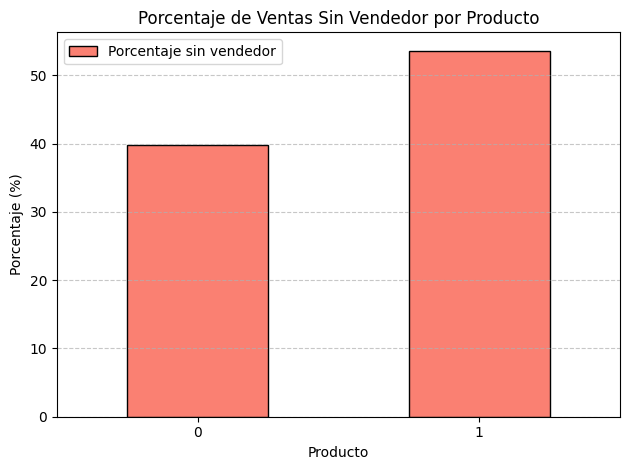

In [ ]:
#creamos un grafico que represente el porcentaje

porcentaje_de_ventas_null  = porcentaje_de_ventas_null.rename_axis(None)

plt.figure(figsize=(8, 5))
porcentaje_de_ventas_null.plot(kind='bar', color='salmon', edgecolor='black')
plt.title('Porcentaje de Ventas Sin Vendedor por Producto')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Producto')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#creamos variables donde conocemos los vendedores y donde no
ventas_sin_vendedor=df[df['Vendedor'].isnull()]
ventas_con_vendedor=df[df['Vendedor'].notnull()]
#creamos un total de ventas donde conocemos los vendedores y donde no 
total_sin_vendedor=ventas_sin_vendedor['Total'].sum()
total_con_vendedor=ventas_con_vendedor['Total'].sum()
#ahora vemos el porcentaje hechos por vendedores no identificados

porcentaje_ventas_sin_vendedor=(total_sin_vendedor/(total_sin_vendedor+total_con_vendedor))*100


AttributeError: 'numpy.float64' object has no attribute 'plot'